In [1]:
import numpy as np
from matplotlib import pyplot as plt
# import modred as mr
import matplotlib.pylab as pylab
# import scipy.io as sio
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import ListedColormap

params={
    'axes.labelsize'  : '24' ,
    'axes.linewidth' : '1.2' ,
    'axes.labelweight': 'bold' ,
#    'font.weight':  'bold' , 
#    'axes.labelcolor':    'red',
# x axis
    'xtick.direction' : 'in' ,
    'xtick.major.size' : '7' ,
    'xtick.major.width' : '1.25' ,
    'xtick.minor.size' : '4.43' ,
    'xtick.minor.width' : '1.25' ,
    'xtick.minor.visible' : 'True' ,
    'xtick.top' : 'True' ,
    'xtick.labelsize' : '24' ,
    'xtick.major.pad' : '10' ,

 #y axis
    'ytick.direction' : 'in' ,
    'ytick.major.size' : '7' ,
    'ytick.major.width' : '1.25' ,
    'ytick.minor.size' : '4.43' ,
    'ytick.minor.width' : '1.25' ,
    'ytick.minor.visible' : 'True' ,
    'ytick.right' : 'True' ,
    'ytick.labelsize' : '24' ,
    'ytick.major.pad' : '10' ,

    'lines.linewidth' : '3.3' ,
#legend
    'legend.fontsize' : '22' ,
    'legend.frameon' : 'False',
    'figure.figsize'    : '8, 8',

#Figure layout
#    'figure.autolayout' : 'True' ,
    'figure.subplot.left':   '0.13 ', # the left side of the subplots of the figure
    'figure.subplot.right':  '0.95',   # the right side of the subplots of the figure
    'figure.subplot.bottom': '0.13',   # the bottom of the subplots of the figure
    'figure.subplot.top':    '0.95',   # the top of the subplots of the figure

##font size
#    'font.size' : '50',

# Use LaTeX for math formatting
    'text.usetex' : 'True',
    'text.latex.preamble' : r'\usepackage{amsmath}',
    'text.latex.preamble' : r'\usepackage{bm}'
}
pylab.rcParams.update(params)

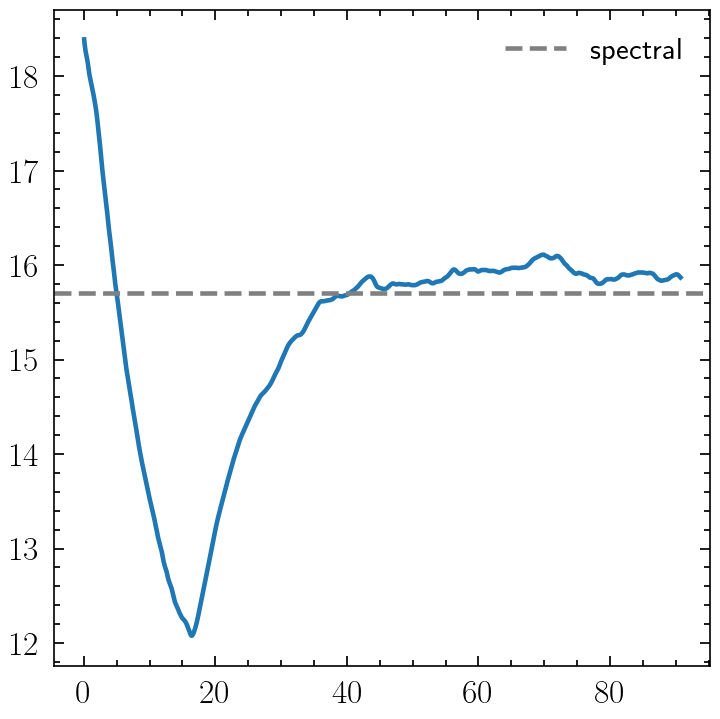

In [2]:
data = np.loadtxt('data/statistics.dat')
nx = 400
ny = 199
nz = 200
H = 100
pi = np.pi; Re = 180.0; visc = 0.0036
u0 = Re*visc/H
ystar = visc / u0
plt.plot(data[:,0]*u0/H,data[:,1]/u0)
plt.axhline(y=15.708, color='grey', linestyle='--', label='spectral')
plt.legend()


data/001300000.dat


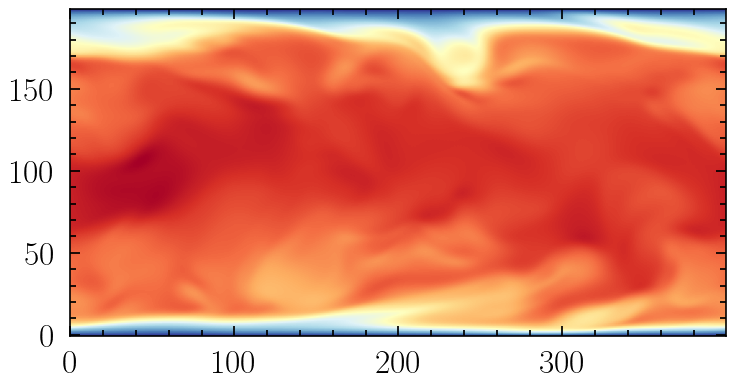

In [3]:
dir = 'data/'

nvariables = 4
nxyz = nx*ny*nz
# nsteps = 30

count = 0
istep = 1300000
finameu = f"{dir}{istep:09d}.dat"
print(finameu)

# read ux
field = np.fromfile(finameu, dtype='float64')
data = field.reshape(nx, ny, nz, nvariables, order ='F')

data_rho = data[:,:,:, 0]
data_u   = data[:,:,:, 1]
data_v   = data[:,:,:, 2]
data_w   = data[:,:,:, 3]
# data_phi = data[:,:,:, 4]
# data_ted = data[:,:,:, 5]
# data_ked = data[:,:,:, 6]

# extract a slice
data_u_plt   = data_u[:,:, 100]
data_v_plt   = data_v[:,:, 100]
data_w_plt   = data_w[:,:, 100]
# print(data_u_plt[2,:])

# calculate the velocity magnitude
# datauv = data_u_plt**2.+  data_v_plt**2. + data_w_plt**2.
# print(datauv.shape)

uw = 0.1
# Grid Mesh
Y, X = np.mgrid[1:nx:ny*1j, 1:nx:ny*1j]
Y = Y - 0.5; X = X - 0.5

plt.imshow(data_u_plt.T, origin='lower', cmap = 'RdYlBu_r')
# plt.streamplot(X, Y, data_u_plt.T, data_v_plt.T, density = 1.5, \
#                linewidth = 0.5, color='black', broken_streamlines=False)
# plt.quiver(X[::5,::5], Y[::5,::5], data_u.T[::5,::5]/uw, data_v.T[::5,::5]/uw, scale = 10)
# plt.xticks([0, 360, 720],['0', '0.5', '1.0'] )
# plt.yticks([0, 360, 720],['0', '0.5', '1.0'] )
# plt.xlim(0, nx)
# plt.ylim(0, nx)
plt.show()

0.4727153354713265


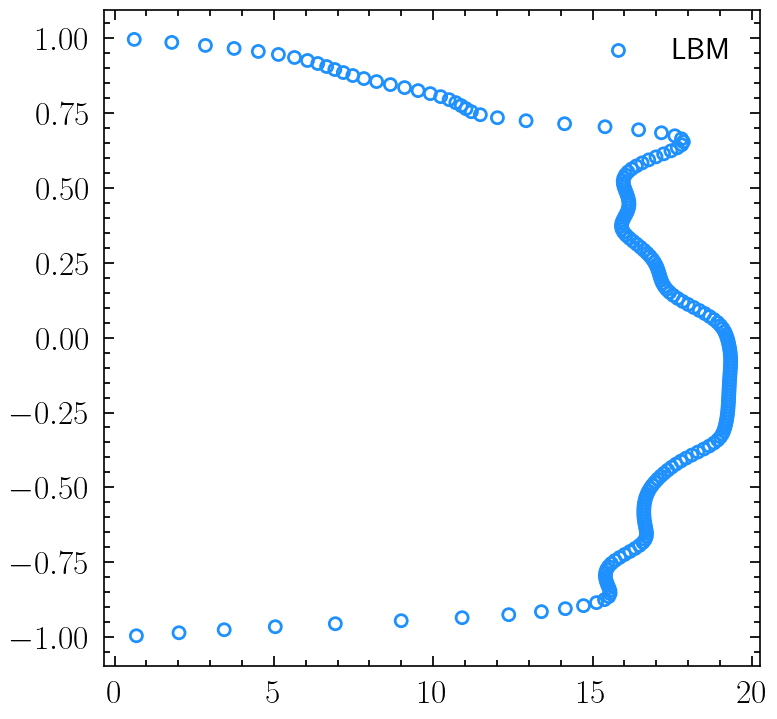

In [4]:
# istep = 10000

x0 = np.linspace(-1+0.5*(2/ny), 1-0.5*(2/ny), ny)
tt = 4. * visc * istep / (ny*ny)
print(tt)

ana = np.zeros(ny)
for i in range (0, ny):
    anatemp = 0.0
    for k in range (0, 101):
        anatemp -= ( (4.*(-1)**(k))/((k+0.5)*pi)**3. * np.cos((k+0.5)*pi*x0[i]) \
            * np.exp(-(k+0.5)**2. * pi**2. *tt) )
    anatemp += 1 - x0[i]**2.
    ana[i] = anatemp
# print(ana)
xx = np.linspace(1, ny, ny)
xx = (xx-(ny/2+0.5))*2/ny
# plt.plot(ana, x0, c='dodgerblue', ls='--', label='ana')
plt.scatter(data_u_plt[2,:]/u0, x0, marker='o', s=75, c='none', edgecolors='dodgerblue', linewidths=2.0, label='LBM')
plt.legend()
plt.show()


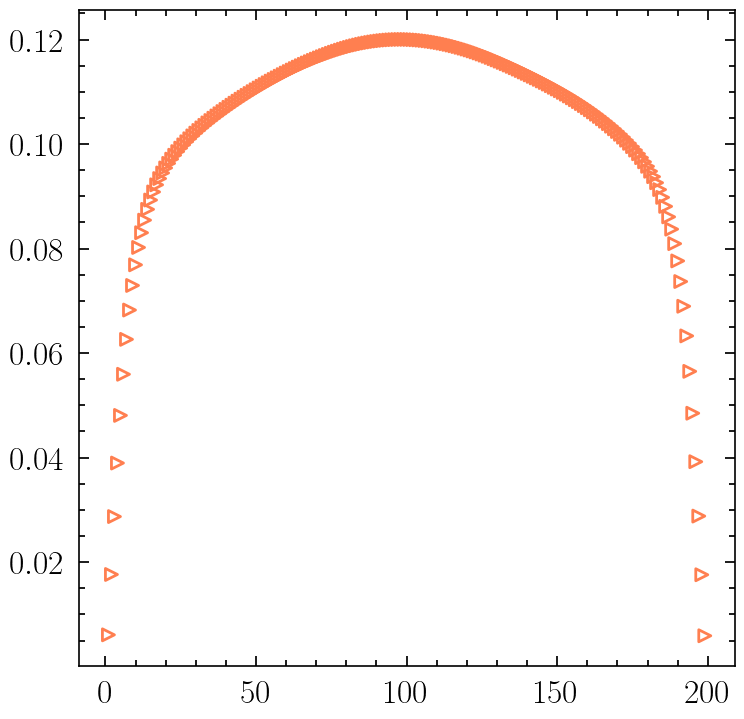

In [5]:
xx = np.linspace(1, ny, ny)
datapro = np.loadtxt('profile_forplt_.txt')
plt.scatter(xx[:],datapro[:,0],color='none', marker='>', edgecolors='coral', \
    s=75, linewidths = 2.0)
plt.show()

In [1]:
x1 = np.linspace(0.5,10,50)
y1 = x1
x2 = np.linspace(9,180,50)
y2 = np.log(x2)/0.40 + 5.5

# uymean = np.zeros(ny)
# for i in range (0, ny):
#     uymean[i] = np.mean(data_u[:,i,:])

plt.scatter(xx[0:H]/ystar, datapro[0:H,0]/u0,color='none', marker='o', edgecolors='#2BB7B3', \
    s=75, linewidths = 2.0, label='BGK')
plt.plot(x1, y1,c='dodgerblue',linestyle='--', alpha =0.8, label=r'$u^+=y^+$')
plt.plot(x2, y2,c='dodgerblue',linestyle='-.', alpha =0.8, label=r'$u^+=\rm{ln}(y^+)/0.40+5.5$')
plt.xscale("log")
plt.xlabel(r'$y^+$')
plt.ylabel(r'$\langle u_x^+\rangle$')
#plt.xlim(-4, 4)
# plt.ylim(0, 24)
plt.legend(handlelength = 3.66)

NameError: name 'np' is not defined

In [7]:
import numpy as np
import os

dir = 'data/'
nvars = 4
file_start = 1000000
file_end   = 1400000
file_step  = 50000
timesteps = list(range(file_start, file_end + 1, file_step))
nfiles = len(timesteps)
print("Total files:", nfiles)

# Arrays for averaging
sum_u  = np.zeros(ny)
sum_v  = np.zeros(ny)
sum_w  = np.zeros(ny)
sum_uu = np.zeros(ny)
sum_vv = np.zeros(ny)
sum_ww = np.zeros(ny)
sum_uv = np.zeros(ny)
sum_uw = np.zeros(ny)
sum_vw = np.zeros(ny)
# compute mean fields
for istep in timesteps:
    fname = f"{dir}{istep:09d}.dat"
    print("Reading:", fname)
    field = np.fromfile(fname, dtype='float64')
    data = field.reshape(nx, ny, nz, nvars, order='F')
    u   = data[:, :, :, 1] / u0
    v   = data[:, :, :, 2] / u0
    w   = data[:, :, :, 3] / u0
    # Mean streamwise-spanwise planes
    sum_u += u.mean(axis=(0,2))
    sum_v += v.mean(axis=(0,2))
    sum_w += w.mean(axis=(0,2))
    meanu = sum_u / nfiles
    meanv = sum_v / nfiles
    meanw = sum_w / nfiles
    # compute Reynolds stress
for istep in timesteps:
    fname = f"{dir}{istep:09d}.dat"
    print("Reading:", fname)
    field = np.fromfile(fname, dtype='float64')
    data = field.reshape(nx, ny, nz, nvars, order='F')
    u   = data[:, :, :, 1] / u0
    v   = data[:, :, :, 2] / u0
    w   = data[:, :, :, 3] / u0
    ur = (u - meanu[np.newaxis, :, np.newaxis])
    vr = (v - meanv[np.newaxis, :, np.newaxis])
    wr = (w - meanw[np.newaxis, :, np.newaxis])
    sum_uu += (ur * ur).mean(axis=(0,2))
    sum_vv += (vr * vr).mean(axis=(0,2))
    sum_ww += (wr * wr).mean(axis=(0,2))
    sum_uv += (ur * vr).mean(axis=(0,2))
    sum_uw += (ur * wr).mean(axis=(0,2))
    sum_vw += (vr * wr).mean(axis=(0,2))
    uu = sum_uu / nfiles
    vv = sum_vv / nfiles
    ww = sum_ww / nfiles
    uv = sum_uv / nfiles
    uw = sum_uw / nfiles
    vw = sum_vw / nfiles
    TKE = 0.5 * (uu + vv + ww)
# Save result
y = np.arange(ny)
out = np.column_stack([y, uu, vv, ww, uv, uw, vw, TKE])
np.savetxt("stats_profile.dat", out,
           header="y   uu   vv   ww   uv   uw   vw   TKE (all nondimensional)")
print("Saved → stats_profile.dat")

Total files: 9
Reading: data/001000000.dat
Reading: data/001050000.dat
Reading: data/001100000.dat
Reading: data/001150000.dat
Reading: data/001200000.dat
Reading: data/001250000.dat
Reading: data/001300000.dat
Reading: data/001350000.dat
Reading: data/001400000.dat
Reading: data/001000000.dat
Reading: data/001050000.dat
Reading: data/001100000.dat
Reading: data/001150000.dat
Reading: data/001200000.dat
Reading: data/001250000.dat
Reading: data/001300000.dat
Reading: data/001350000.dat
Reading: data/001400000.dat
Saved → stats_profile.dat


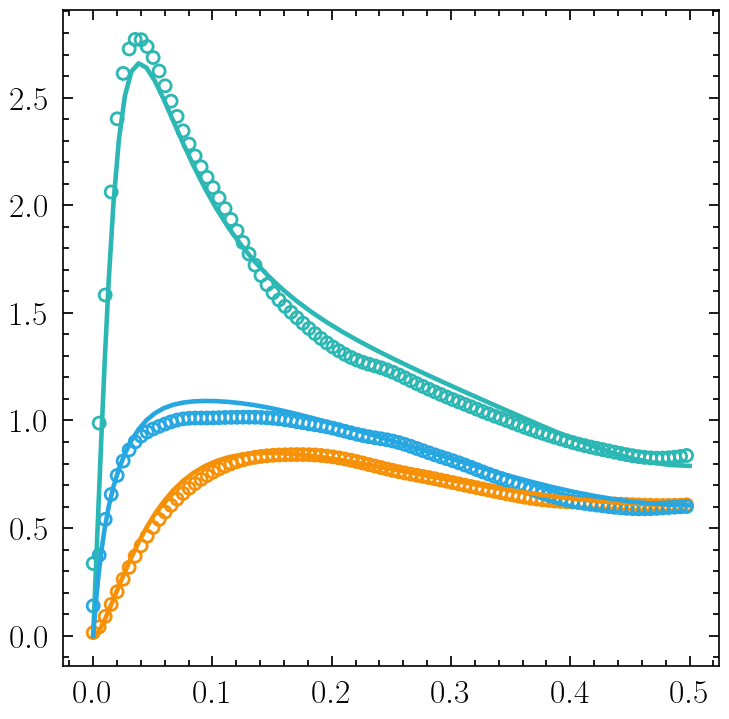

In [10]:
data = np.loadtxt('stats_profile.dat')
dataspec = np.loadtxt('Re180.prof')
yspec = dataspec[:,0] / 2
uspec = dataspec[:,3]
vspec = dataspec[:,4]
wspec = dataspec[:,5]
plt.plot(yspec, uspec,color = '#2BB7B3')
plt.plot(yspec, vspec,color = '#F69007')
plt.plot(yspec, wspec,color = '#26A7E1')

y = data[0:H,0] / ny
urms = np.sqrt(data[0:H,1])
vrms = np.sqrt(data[0:H,2])
wrms = np.sqrt(data[0:H,3])
plt.scatter(y,urms,edgecolors = '#2BB7B3', facecolors='none', s=75,linewidths=2)
plt.scatter(y,vrms,edgecolors = '#F69007', facecolors='none', s=75,linewidths=2)
plt.scatter(y,wrms,edgecolors = '#26A7E1', facecolors='none', s=75,linewidths=2)
# plt.plot(y,vrms)
# plt.plot(y,wrms)

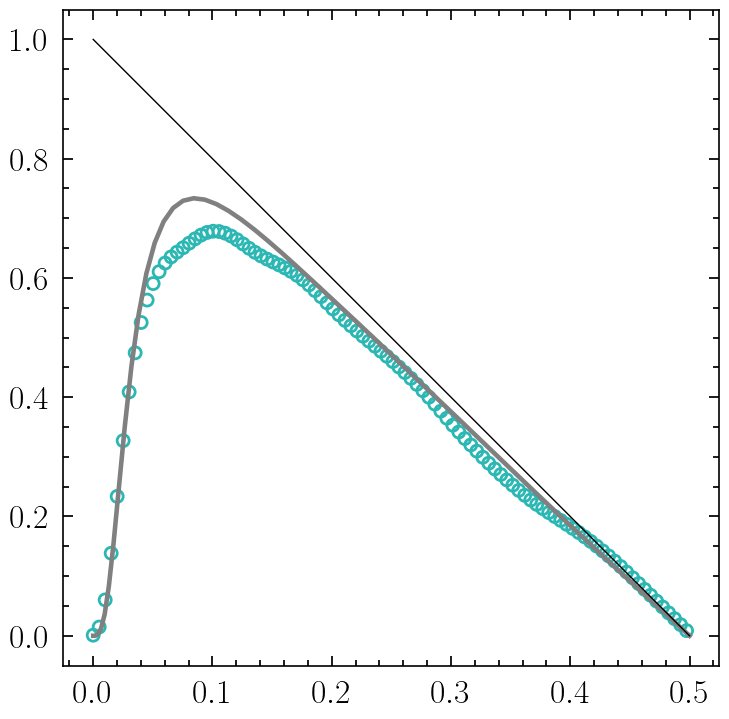

In [11]:
res = -(data[0:H,4])
resspc = dataspec[:,9]
plt.scatter(y,res,edgecolors = '#2BB7B3', facecolors='none', s=75,linewidths=2)

plt.plot(yspec, -dataspec[:,10],color='grey')

plt.plot([0, 0.5], [1, 0], color='black', linestyle='-', linewidth=1)      

# plt.plot(y,vrms)
# plt.plot(y,wrms)